In [10]:


import pandas as pd

df = pd.read_csv('csv/search_comments_2026-04-08.csv')
print(df.shape)
print(df.columns.tolist())
df.head(3)

(1916, 13)
['comment_id', 'create_time', 'ip_location', 'note_id', 'content', 'user_id', 'nickname', 'avatar', 'sub_comment_count', 'pictures', 'parent_comment_id', 'last_modify_ts', 'like_count']


,comment_id,create_time,ip_location,note_id,content,user_id,nickname,avatar,sub_comment_count,pictures,parent_comment_id,last_modify_ts,like_count
0,6912f6ce00000000390211de,1762850510000,浙江,6911eccc0000000007036a2a,原来老师当年是这个意思啊,60c03e080000000001006022,校服厂家直供,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,28,NaN,0,1775658007128,795
1,69132d3a0000000039028a98,1762864447000,广东,6911eccc0000000007036a2a,我也有哦 呵呵,5d3dfc82000000001601c90e,虧、,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,3,http://sns-webpic-qc.xhscdn.com/202604082220/1...,0,1775658007129,85
2,691330df0000000039032555,1762865376000,四川,6911eccc0000000007036a2a,@玧其尼 @不想取名 @某人在星空破晓 真不行了感觉成绩出来后可以拍,5cd02808000000001200b358,学习与我注定无缘,https://sns-avatar-qc.xhscdn.com/avatar/1040g2...,2,NaN,0,1775658007130,2


In [11]:
def build_absa_samples(text, aspects=['成分', '功效', '肤感']):
    """
    把一条评论 × 三个aspect，构造成三条ABSA输入样本
    返回：[(输入文本, aspect, 原始评论), ...]
    """
    samples = []
    for asp in aspects:
        absa_input = f"{text}[ASP]{asp}[ASP]"
        samples.append((absa_input, asp, text))
    return samples

# 测试一下
test = build_absa_samples("这款精华烟酰胺成分很扎实，但是肤感有点油腻")
for s in test:
    print(s[0])

这款精华烟酰胺成分很扎实，但是肤感有点油腻[ASP]成分[ASP]
这款精华烟酰胺成分很扎实，但是肤感有点油腻[ASP]功效[ASP]
这款精华烟酰胺成分很扎实，但是肤感有点油腻[ASP]肤感[ASP]


In [12]:
import os
import logging
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
logging.getLogger('huggingface_hub').setLevel(logging.ERROR)
logging.getLogger('transformers').setLevel(logging.ERROR)

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# 用中文情感分析模型（专门针对中文评论训练的）
model_name = "lxyuan/distilbert-base-multilingual-cased-sentiments-student"

tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(model_name, local_files_only=True)
model.eval()

print("模型加载成功")
print("标签:", model.config.id2label)

模型加载成功
标签: {0: 'positive', 1: 'neutral', 2: 'negative'}


In [13]:
def predict_sentiment(text, aspect):
    """
    针对某个aspect，预测情感极性
    思路：把aspect词拼接到评论里，让模型关注该维度
    """
    # 构造输入：评论 + aspect提示
    input_text = f"{text} 关于{aspect}的感受："
    
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=True
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred_id].item()
    
    label = model.config.id2label[pred_id]  # positive/negative/neutral
    return label, round(confidence, 3)

# 测试
test_cases = [
    ("这款精华烟酰胺成分很扎实，浓度够", "成分"),
    ("用了两周完全没有提亮效果，很失望", "功效"),
    ("上脸有点油腻，夏天用不太舒服", "肤感"),
]

for text, asp in test_cases:
    label, conf = predict_sentiment(text, asp)
    print(f"[{asp}] {text[:20]}... → {label} ({conf:.1%})")

[成分] 这款精华烟酰胺成分很扎实，浓度够... → positive (92.3%)
[功效] 用了两周完全没有提亮效果，很失望... → negative (86.6%)
[肤感] 上脸有点油腻，夏天用不太舒服... → negative (83.8%)


In [14]:
import pandas as pd
from tqdm.auto import tqdm

aspects = ['成分', '功效', '肤感']
comment_col = 'content'  # ← 根据你的实际列名修改

comments = df[comment_col].dropna().tolist()
print(f"评论总数: {len(comments)}")

records = []
for comment in tqdm(comments, desc="处理进度", disable=True):
    for asp in aspects:
        label, conf = predict_sentiment(str(comment), asp)
        records.append({
            'comment': comment,
            'aspect': asp,
            'sentiment': label,
            'confidence': conf
        })

df_result = pd.DataFrame(records)
df_result.to_csv('absa_results.csv', index=False, encoding='utf-8-sig')
print(f"完成！共 {len(df_result)} 条记录")
df_result.head(9)

评论总数: 1914
完成！共 5742 条记录


,comment,aspect,sentiment,confidence
0,原来老师当年是这个意思啊,成分,positive,0.637
1,原来老师当年是这个意思啊,功效,positive,0.589
2,原来老师当年是这个意思啊,肤感,positive,0.468
3,我也有哦 呵呵,成分,positive,0.844
4,我也有哦 呵呵,功效,positive,0.873
5,我也有哦 呵呵,肤感,positive,0.826
6,@玧其尼 @不想取名 @某人在星空破晓 真不行了感觉成绩出来后可以拍,成分,negative,0.678
7,@玧其尼 @不想取名 @某人在星空破晓 真不行了感觉成绩出来后可以拍,功效,negative,0.700
8,@玧其尼 @不想取名 @某人在星空破晓 真不行了感觉成绩出来后可以拍,肤感,negative,0.708


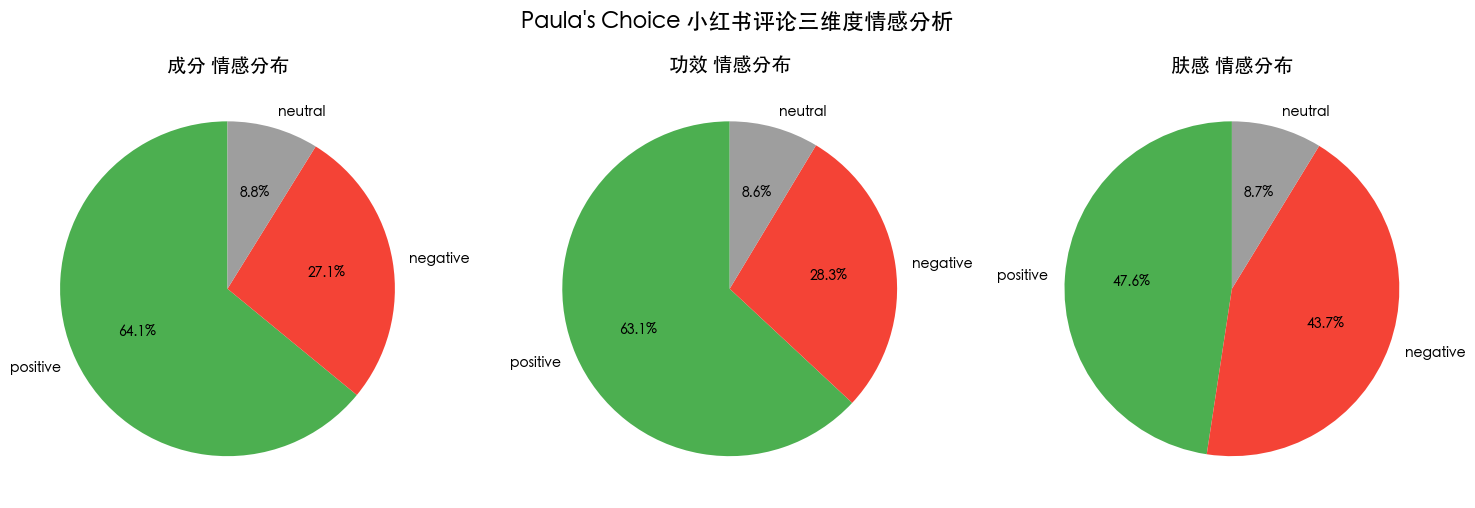

成分:  正面 64.1%  负面 27.1%  中性 8.8%
功效:  正面 63.1%  负面 28.3%  中性 8.6%
肤感:  正面 47.6%  负面 43.7%  中性 8.7%


In [15]:
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager

cjk_font_candidates = [
    'Heiti TC', 'Songti SC', 'PingFang SC', 'Arial Unicode MS',
    'Noto Sans CJK SC', 'Microsoft YaHei', 'SimHei'
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in cjk_font_candidates:
    if font_name in available_fonts:
        matplotlib.rcParams['font.family'] = 'sans-serif'
        matplotlib.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
        break
matplotlib.rcParams['axes.unicode_minus'] = False

# 各aspect情感分布
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, asp in enumerate(['成分', '功效', '肤感']):
    subset = df_result[df_result['aspect'] == asp]
    counts = subset['sentiment'].value_counts()
    colors = ['#4CAF50' if l == 'positive' else '#F44336' if l == 'negative' else '#9E9E9E' 
              for l in counts.index]
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', 
                startangle=90, colors=colors)
    axes[i].set_title(f'{asp} 情感分布', fontsize=14)

plt.suptitle("Paula's Choice 小红书评论三维度情感分析", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印关键数字
print("=" * 45)
for asp in ['成分', '功效', '肤感']:
    subset = df_result[df_result['aspect'] == asp]
    pos = (subset['sentiment'] == 'positive').mean()
    neg = (subset['sentiment'] == 'negative').mean()
    neu = (subset['sentiment'] == 'neutral').mean()
    print(f"{asp}:  正面 {pos:.1%}  负面 {neg:.1%}  中性 {neu:.1%}")
print("=" * 45)

In [16]:
# 只保留置信度 > 0.6 的结果，过滤掉模型不确定的预测
df_high_conf = df_result[df_result['confidence'] > 0.6].copy()

print(f"过滤前: {len(df_result)} 条")
print(f"过滤后: {len(df_high_conf)} 条")
print(f"保留率: {len(df_high_conf)/len(df_result):.1%}")
print()

# 过滤后重新统计
print("高置信度样本统计：")
print("=" * 45)
for asp in ['成分', '功效', '肤感']:
    subset = df_high_conf[df_high_conf['aspect'] == asp]
    pos = (subset['sentiment'] == 'positive').mean()
    neg = (subset['sentiment'] == 'negative').mean()
    print(f"{asp}:  正面 {pos:.1%}  负面 {neg:.1%}  样本数 {len(subset)}")
print("=" * 45)

过滤前: 5742 条
过滤后: 2491 条
保留率: 43.4%

高置信度样本统计：
成分:  正面 69.4%  负面 24.8%  样本数 900
功效:  正面 68.0%  负面 27.0%  样本数 893
肤感:  正面 51.0%  负面 41.5%  样本数 698


In [17]:
import re
from collections import Counter

try:
    import jieba
except ModuleNotFoundError:
    jieba = None
    print("提示：当前 kernel 没有安装 jieba，已使用正则分词兜底。若要使用 jieba，请切换到 Python 3 (ipykernel) 或安装 jieba。")

if 'df_high_conf' not in globals():
    df_result = pd.read_csv('absa_results.csv')
    df_high_conf = df_result[df_result['confidence'] > 0.6].copy()

skincare_words = ['烟酰胺', '水杨酸', '玻尿酸', '角鲨烷', '神经酰胺',
                  '视黄醇', '积雪草', '烟酰胺精华', '宝拉珍选', '防晒',
                  '提亮', '补水', '控油', '抗老', '刺激', '油腻', '清爽']
if jieba is not None:
    for w in skincare_words:
        jieba.add_word(w)

# 扩充停用词，加入emoji文字和无意义词
stopwords = set([
    '的', '了', '是', '在', '我', '有', '和', '就', '都', '也', '这', '个',
    '用', '感觉', '觉得', '真的', '一个', '没有', '不是', '可以', '因为',
    '所以', '但是', '然后', '这个', '什么', '请问', '我用', '有点', '现在',
    '宝拉', '一直', '还是', '已经', '一种', '不会', '还有', '知道', '自己',
    # emoji文字描述
    '飞吻', '偷笑', '害羞', '捂脸', '发光', '玫瑰', '爱心', '强壮',
    '庆祝', '闪光', '加油', '微笑', '大哭', '惊喜', '色值', '哈哈'
])

def tokenize_text(text):
    if jieba is not None:
        return jieba.cut(str(text))
    return re.findall(r'[\u4e00-\u9fff]{2,}|[A-Za-z]{2,}', str(text))

def get_keywords(texts, top_n=10):
    words = []
    for text in texts:
        for w in tokenize_text(text):
            if len(w) >= 2 and w not in stopwords:
                words.append(w)
    return Counter(words).most_common(top_n)

print("=" * 55)
for asp in ['成分', '功效', '肤感']:
    for sentiment in ['positive', 'negative']:
        subset = df_high_conf[
            (df_high_conf['aspect'] == asp) &
            (df_high_conf['sentiment'] == sentiment)
        ]['comment']
        keywords = get_keywords(subset, top_n=8)
        label = "✅正面" if sentiment == 'positive' else "❌负面"
        print(f"\n【{asp}】{label} 高频词：")
        print("  " + "  ".join([f"{w}({n})" for w, n in keywords]))
print("=" * 55)

提示：当前 kernel 没有安装 jieba，已使用正则分词兜底。若要使用 jieba，请切换到 Python 3 (ipykernel) 或安装 jieba。

【成分】✅正面 高频词：
  点赞(19)  笑哭(18)  派对(15)  萌萌哒(14)  ml(14)  vc(13)  哭惹(13)  皱眉(12)

【成分】❌负面 高频词：
  哭惹(58)  笑哭(57)  失望(28)  你好(6)  毛孔粗大(6)  姐妹(6)  doge(4)  每次用一泵脸就泛白搓泥(4)

【功效】✅正面 高频词：
  点赞(19)  笑哭(18)  派对(15)  萌萌哒(14)  ml(14)  vc(13)  哭惹(13)  皱眉(12)

【功效】❌负面 高频词：
  笑哭(62)  哭惹(60)  失望(30)  托托(6)  你好(6)  毛孔粗大(6)  姐妹(6)  doge(4)

【肤感】✅正面 高频词：
  点赞(19)  笑哭(16)  ml(14)  哭惹(13)  皱眉(12)  萌萌哒(11)  大笑(11)  烟酰胺(10)

【肤感】❌负面 高频词：
  笑哭(72)  哭惹(70)  失望(30)  姐妹(9)  毛孔粗大(8)  托托(6)  搓泥(6)  你好(6)
